In [ ]:
import pandas as pd
import numpy as np
import joblib

try:
    # If you saved using joblib from Day 3
    data = joblib.load('prepared_data.pkl')
    X = data['X']
    y = data['y']
    print(" Loaded prepared_data.pkl")
except:
    try:
        # If you saved as CSV
        df = pd.read_csv('ml_ready_data.csv')
        # Assuming last column is target
        X = df.iloc[:, :-1]
        y = df.iloc[:, -1]
        print(" Loaded ml_ready_data.csv")
    except:
        # Load from Day 2 cleaned data
        print("  Loading from Day 2 cleaned data...")
        df = pd.read_csv('telco_churn_cleaned.csv')
        
        # Quick feature engineering
        df['TotalServices'] = 0
        service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 
                       'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies']
        
        for col in service_cols:
            if col in df.columns:
                df[f'{col}_bin'] = df[col].apply(lambda x: 1 if x in ['Yes'] else 0)
                df['TotalServices'] += df[f'{col}_bin']
        
        # Encoding
        binary_map = {'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1}
        for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']:
            if col in df.columns:
                df[f'{col}_enc'] = df[col].map(binary_map)

        # Contract encoding - FIXED for your issue!
        print("\n Fixing contract encoding...")
        df['Contract'] = df['Contract'].str.strip()  # Remove spaces
        contract_map = {'Month-to-month': 2, 'One year': 1, 'Two year': 0}
        df['Contract_enc'] = df['Contract'].map(contract_map)
        
        # Check for any unmapped values
        if df['Contract_enc'].isna().any():
            print("  Found unmapped contract values:")
            print(df[df['Contract_enc'].isna()]['Contract'].value_counts())
            # Fill with mode
            df['Contract_enc'].fillna(df['Contract_enc'].mode()[0], inplace=True)
        
        df['Churn_enc'] = df['Churn'].map({'Yes': 1, 'No': 0})
        
        # Select features
        features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen',
                   'TotalServices', 'gender_enc', 'Partner_enc', 'Dependents_enc',
                   'Contract_enc', 'PaperlessBilling_enc']
        
        # Only keep features that exist
        available_features = [f for f in features if f in df.columns]
        X = df[available_features]
        y = df['Churn_enc']
        print(f" Created features: {available_features}")

print(f"\n Data shape: {X.shape}")
print(f" Features: {list(X.columns)}")
print(f" Target distribution:\n{y.value_counts()}")

print("\n Data is ready for modeling!")

✅ Loaded prepared_data.pkl

📊 Data shape: (7043, 16)
📋 Features: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'TotalServices', 'PremiumServices', 'ContractRisk', 'PaymentRisk', 'RiskScore', 'gender_encoded', 'Partner_encoded', 'Dependents_encoded', 'PhoneService_encoded', 'PaperlessBilling_encoded', 'InternetService_encoded', 'Contract_encoded']
🎯 Target distribution:
Churn_encoded
0    5174
1    1869
Name: count, dtype: int64

✅ Data is ready for modeling!


In [24]:
#DAY 4: BUILDING YOUR FIRST ML MODEL!

#import ml Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import(accuracy_score,precision_score,recall_score,
                            f1_score,roc_auc_score,confusion_matrix,
                            classification_report,roc_curve)
import warnings
warnings.filterwarnings('ignore')
print('ml Libraries imported successfully')

ml Libraries imported successfully


In [25]:
print("STEP 1: LOADING AND SPLITTING DATA")

#load the prepare data
try:
    data=joblib('prepared_data.pkl')
    X=data['X']
    y=data['y']
    print('Loaded prepared data.pkl')
except:
    print('using quick check data from above')

print(f'Feature Matrix {X.shape}')
print(f'Target Vector{y.shape}')

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(f'Training set size:{X_train.shape[0]}samples')
print(f'Testing set size{X_test.shape[0]}samples')

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

print('feature scaled successfully')

STEP 1: LOADING AND SPLITTING DATA
using quick check data from above
Feature Matrix (7043, 16)
Target Vector(7043,)
Training set size:5634samples
Testing set size1409samples
feature scaled successfully


In [ ]:
print("STEP 2: TRAINING LOGISTIC REGRESSION")

print('Training Logistic Regression')

lr_model=LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train_scaled,y_train)

y_pred_lr=lr_model.predict(X_test_scaled)
y_pred_proba_lr=lr_model.predict_proba(X_test_scaled)[:,1]

#Calculate Metrics

accuracy_lr=accuracy_score(y_test,y_pred_lr)
precision_lr=precision_score(y_test,y_pred_lr)
recall_lr=recall_score(y_test,y_pred_lr)
f1_lr=f1_score(y_test,y_pred_lr)
roc_auc_lr=roc_auc_score(y_test,y_pred_lr)

print("\n Logistic Regression Performance:")
print(f'Accuracy score {accuracy_lr:.4f}')
print(f'precision_score {precision_lr:.4f}')
print(f'recall_score{recall_lr:.4f}')
print(f'f1_score{f1_lr:.4f}')
print(f'roc_auc_score{roc_auc_lr:.4f}')


feature_importance=pd.DataFrame({
    'feature':X.columns,
    'coefficient':lr_model.coef_[0]
}).sort_values('coefficient',key=abs,ascending=False)


print("\n Top 5 most important features (by coefficient):")
print(feature_importance.head(5).to_string(index=False))

STEP 2: TRAINING LOGISTIC REGRESSION
Training Logistic Regression

📊 Logistic Regression Performance:
Accuracy score 0.7999
precision_score 0.6523
recall_score0.5267
f1_score0.5828
roc_auc_score0.7126

🔍 Top 5 most important features (by coefficient):
                feature  coefficient
         MonthlyCharges     1.787387
                 tenure    -0.920070
        PremiumServices    -0.839713
              RiskScore     0.618363
InternetService_encoded    -0.565558


In [27]:
#Random Forest 

rf_model=RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_train,y_train)

y_pred_rf=rf_model.predict(X_test)
y_pred_proba_rf=rf_model.predict_proba(X_test)[:,1]

#calculate Metrics

accuracy_rf=accuracy_score(y_test,y_pred_rf)
precision_rf=precision_score(y_test,y_pred_rf)
recall_rf=recall_score(y_test,y_pred_rf)
f1_rf=f1_score(y_test,y_pred_rf)
roc_auc_rf=roc_auc_score(y_test,y_pred_rf)


print(f'Accuracy:{accuracy_rf:.4f}')
print(f'Precision:{precision_rf:.4f}')
print(f'recall:{recall_rf:.4f}')
print(f'f1_score:{f1_rf:.4f}')
print(f'ROC_auc:{roc_auc_rf:.4f}')

rf_importance=pd.DataFrame({
    'feature':X.columns,
    'importance':rf_model.feature_importances_
}).sort_values('importance',ascending=False)


print(rf_importance.head(5).to_string(index=False))

Accuracy:0.8027
Precision:0.6548
recall:0.5428
f1_score:0.5936
ROC_auc:0.7197
         feature  importance
       RiskScore    0.167228
  MonthlyCharges    0.147172
    TotalCharges    0.144099
          tenure    0.128815
Contract_encoded    0.079721



STEP 4: COMPARING MODELS

📊 Model Comparison:
   Metric  Logistic Regression  Random Forest
 Accuracy             0.799858       0.802697
Precision             0.652318       0.654839
   Recall             0.526738       0.542781
 F1-Score             0.582840       0.593567
  ROC-AUC             0.712644       0.719700


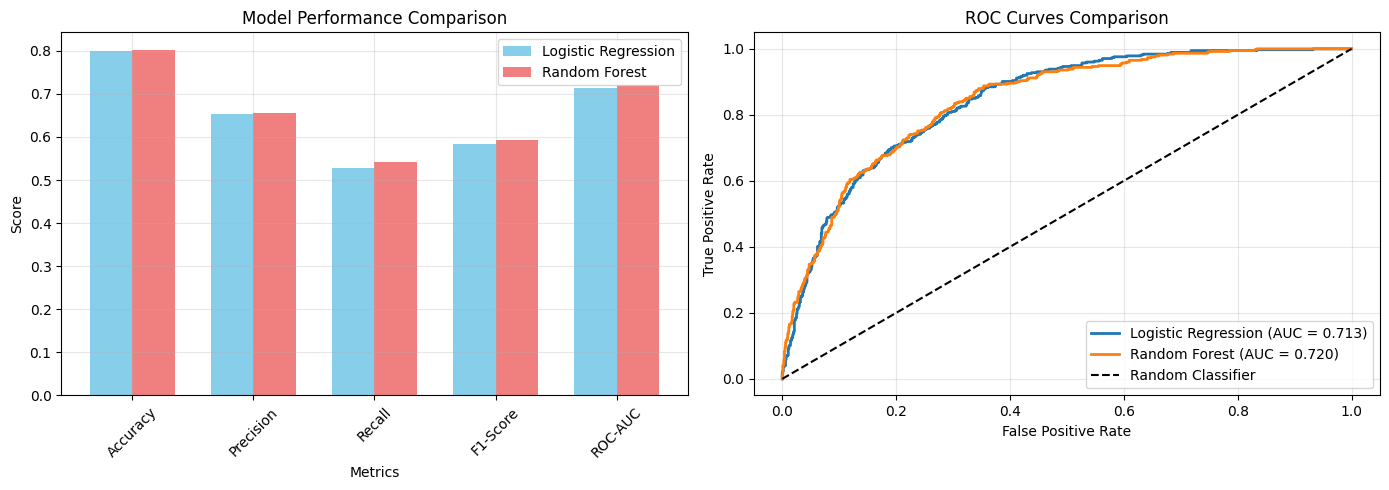

In [ ]:
print("\n" + "=" * 60)
print("STEP 4: COMPARING MODELS")
print("=" * 60)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr, roc_auc_lr],
    'Random Forest': [accuracy_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]
})

print("\n Model Comparison:")
print(comparison.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparison
x = np.arange(len(comparison['Metric']))
width = 0.35

axes[0].bar(x - width/2, comparison['Logistic Regression'], width, 
            label='Logistic Regression', color='skyblue')
axes[0].bar(x + width/2, comparison['Random Forest'], width,
            label='Random Forest', color='lightcoral')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Metric'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

axes[1].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})', 
             linewidth=2)
axes[1].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.3f})', 
             linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


STEP 5: CONFUSION MATRICES


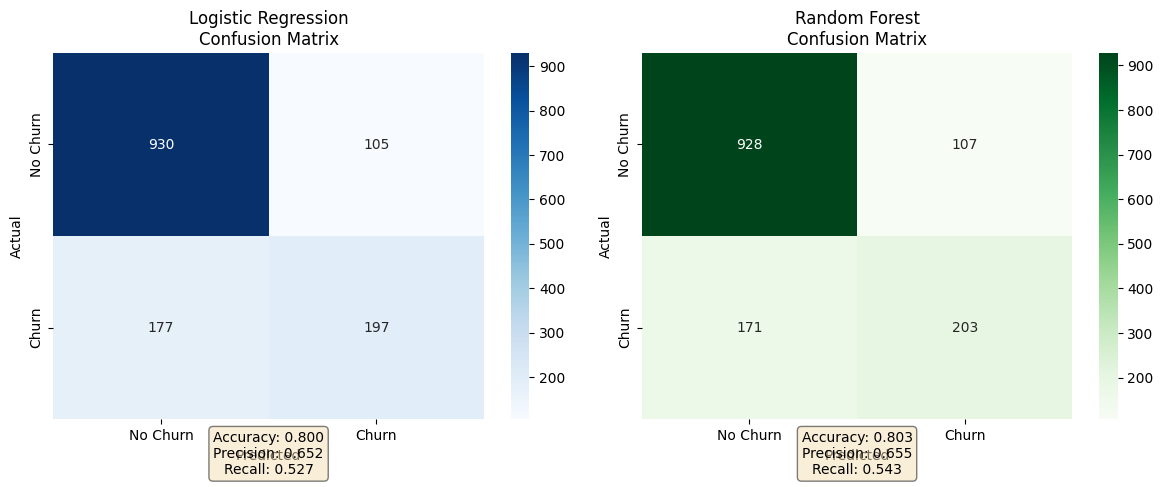

In [29]:
print("\n" + "=" * 60)
print("STEP 5: CONFUSION MATRICES")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Add metrics annotation
axes[0].text(0.5, -0.15, 
             f'Accuracy: {accuracy_lr:.3f}\nPrecision: {precision_lr:.3f}\nRecall: {recall_lr:.3f}',
             transform=axes[0].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
axes[1].set_title('Random Forest\nConfusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

axes[1].text(0.5, -0.15, 
             f'Accuracy: {accuracy_rf:.3f}\nPrecision: {precision_rf:.3f}\nRecall: {recall_rf:.3f}',
             transform=axes[1].transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()


STEP 6: MAKING PREDICTIONS ON NEW CUSTOMERS

📋 Features in your model: ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'TotalServices', 'PremiumServices', 'ContractRisk', 'PaymentRisk', 'RiskScore', 'gender_encoded', 'Partner_encoded', 'Dependents_encoded', 'PhoneService_encoded', 'PaperlessBilling_encoded', 'InternetService_encoded', 'Contract_encoded']
   ⚠️  Using zeros for unknown feature: PaperlessBilling_encoded

✅ Created sample customers with 16 features

🔮 Predictions for Sample Customers:
              Customer  Tenure Contract  LR_Churn_Prob  RF_Churn_Prob LR_Prediction RF_Prediction
        New (2 months)       2  Unknown       0.385520       0.545150        🟢 STAY       🔴 CHURN
Short-term (12 months)      12  Unknown       0.070944       0.286283        🟢 STAY        🟢 STAY
  Mid-term (36 months)      36  Unknown       0.004234       0.039957        🟢 STAY        🟢 STAY
 Long-term (60 months)      60  Unknown       0.000568       0.005889        🟢 STAY      

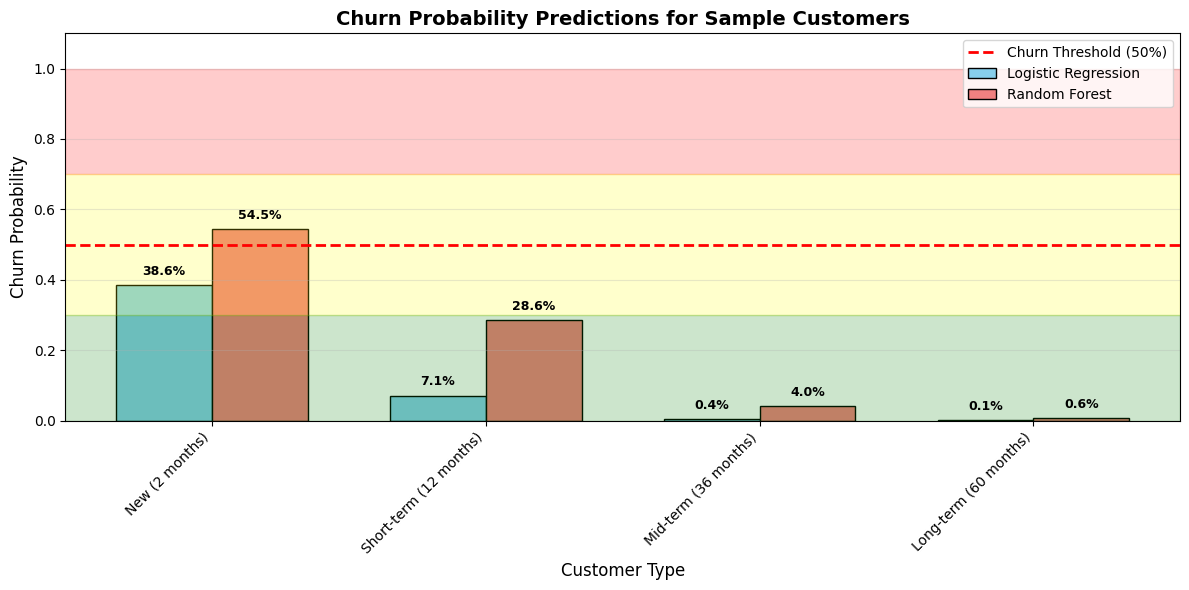


💼 BUSINESS RECOMMENDATIONS:
--------------------------------------------------
🟡 WARNING: New (2 months) - 54.5% churn risk
   → Send targeted retention email
   → Consider contract upgrade offer
🟢 LOW RISK: Short-term (12 months) - 28.6% churn risk
   → Maintain regular engagement
   → Look for upsell opportunities
🟢 LOW RISK: Mid-term (36 months) - 4.0% churn risk
   → Maintain regular engagement
   → Look for upsell opportunities
🟢 LOW RISK: Long-term (60 months) - 0.6% churn risk
   → Maintain regular engagement
   → Look for upsell opportunities


In [ ]:
print("MAKING PREDICTIONS ON NEW CUSTOMERS")


# First, let's see what features we actually have
print(f"\n Features in your model: {list(X.columns)}")

# Create sample customers dynamically based on your actual features
def create_sample_customers(feature_names):
    """
    Create sample customers that match your feature set
    """
    # Start with basic customer data
    n_samples = 4
    sample_data = {}
    
    # For each feature, provide appropriate sample values
    for feature in feature_names:
        if feature == 'tenure':
            sample_data[feature] = [2, 12, 36, 60]
        elif feature == 'MonthlyCharges':
            sample_data[feature] = [80, 65, 50, 45]
        elif feature == 'TotalCharges':
            sample_data[feature] = [160, 780, 1800, 2700]
        elif feature == 'SeniorCitizen':
            sample_data[feature] = [0, 1, 0, 0]
        elif feature == 'TotalServices':
            sample_data[feature] = [2, 3, 4, 5]
        elif feature == 'gender_enc' or feature == 'gender_encoded':
            sample_data[feature] = [1, 0, 1, 0]  # 1=Male, 0=Female
        elif feature == 'Partner_enc' or feature == 'Partner_encoded':
            sample_data[feature] = [0, 1, 1, 1]  # 1=Has partner
        elif feature == 'Dependents_enc' or feature == 'Dependents_encoded':
            sample_data[feature] = [0, 0, 1, 1]  # 1=Has dependents
        elif feature == 'Contract_enc' or feature == 'Contract_encoded':
            sample_data[feature] = [2, 2, 1, 0]  # 2=Month-to-month, 1=One year, 0=Two year
        elif feature == 'PaperlessBilling_enc':
            sample_data[feature] = [1, 1, 0, 0]
        elif feature == 'PhoneService_enc' or feature == 'PhoneService_encoded':
            sample_data[feature] = [1, 1, 1, 1]
        elif feature == 'InternetService_enc' or feature == 'InternetService_encoded':
            sample_data[feature] = [2, 2, 1, 1]  # 2=Fiber optic, 1=DSL
        elif feature == 'MultipleLines_binary':
            sample_data[feature] = [1, 1, 1, 0]
        elif feature == 'OnlineSecurity_binary':
            sample_data[feature] = [0, 0, 1, 1]
        elif feature == 'OnlineBackup_binary':
            sample_data[feature] = [0, 1, 1, 1]
        elif feature == 'DeviceProtection_binary':
            sample_data[feature] = [0, 0, 1, 1]
        elif feature == 'TechSupport_binary':
            sample_data[feature] = [0, 0, 1, 1]
        elif feature == 'StreamingTV_binary':
            sample_data[feature] = [0, 1, 1, 1]
        elif feature == 'StreamingMovies_binary':
            sample_data[feature] = [0, 1, 1, 1]
        elif feature == 'PremiumServices':
            sample_data[feature] = [0, 2, 4, 5]
        elif feature == 'ContractRisk':
            sample_data[feature] = [3, 3, 2, 1]
        elif feature == 'PaymentRisk':
            sample_data[feature] = [3, 2, 1, 1]
        elif feature == 'RiskScore':
            sample_data[feature] = [0.8, 0.6, 0.3, 0.2]
        elif feature == 'AvgChargePerMonth':
            sample_data[feature] = [40, 54, 50, 45]
        else:
            # For any unknown features, use zeros
            print(f"     Using zeros for unknown feature: {feature}")
            sample_data[feature] = [0, 0, 0, 0]
    
    return pd.DataFrame(sample_data)

# Create sample customers that match your features
sample_customers = create_sample_customers(X.columns)
print(f"\n Created sample customers with {len(X.columns)} features")

# Make sure columns are in the same order
sample_customers = sample_customers[X.columns]

# Scale for logistic regression
sample_scaled = scaler.transform(sample_customers)

# Predict using both models
lr_probs = lr_model.predict_proba(sample_scaled)[:, 1]
rf_probs = rf_model.predict_proba(sample_customers)[:, 1]

# Create customer descriptions based on tenure
customer_types = []
for tenure in sample_customers['tenure']:
    if tenure <= 6:
        customer_types.append(f'New ({tenure} months)')
    elif tenure <= 24:
        customer_types.append(f'Short-term ({tenure} months)')
    elif tenure <= 48:
        customer_types.append(f'Mid-term ({tenure} months)')
    else:
        customer_types.append(f'Long-term ({tenure} months)')

# Create contract descriptions
contract_descriptions = []
if 'Contract_enc' in sample_customers.columns:
    for val in sample_customers['Contract_enc']:
        if val == 2:
            contract_descriptions.append('Month-to-month')
        elif val == 1:
            contract_descriptions.append('One year')
        else:
            contract_descriptions.append('Two year')
else:
    contract_descriptions = ['Unknown'] * len(sample_customers)

# Create results dataframe
results = pd.DataFrame({
    'Customer': customer_types,
    'Tenure': sample_customers['tenure'],
    'Contract': contract_descriptions,
    'LR_Churn_Prob': lr_probs,
    'RF_Churn_Prob': rf_probs,
    'LR_Prediction': ['🔴 CHURN' if p > 0.5 else '🟢 STAY' for p in lr_probs],
    'RF_Prediction': ['🔴 CHURN' if p > 0.5 else '🟢 STAY' for p in rf_probs]
})

print("\n🔮 Predictions for Sample Customers:")

print(results.to_string(index=False))


# Visualize predictions
plt.figure(figsize=(12, 6))
x = np.arange(len(results))
width = 0.35

bars1 = plt.bar(x - width/2, results['LR_Churn_Prob'], width, 
                label='Logistic Regression', color='skyblue', edgecolor='black')
bars2 = plt.bar(x + width/2, results['RF_Churn_Prob'], width,
                label='Random Forest', color='lightcoral', edgecolor='black')

# Add threshold line
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=2, 
            label='Churn Threshold (50%)')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Churn Probability', fontsize=12)
plt.title('Churn Probability Predictions for Sample Customers', fontsize=14, fontweight='bold')
plt.xticks(x, results['Customer'], rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3, axis='y')

# Add a background color for risk zones
plt.axhspan(0.7, 1.0, alpha=0.2, color='red', label='High Risk')
plt.axhspan(0.3, 0.7, alpha=0.2, color='yellow', label='Medium Risk')
plt.axhspan(0, 0.3, alpha=0.2, color='green', label='Low Risk')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100, bbox_inches='tight')
plt.show()

# Print business recommendations
print("\n💼 BUSINESS RECOMMENDATIONS:")

for i, row in results.iterrows():
    if row['RF_Churn_Prob'] > 0.7:
        print(f"🔴 URGENT: {row['Customer']} - {row['RF_Churn_Prob']:.1%} churn risk")
        print(f"   → Offer retention discount immediately")
        print(f"   → Schedule personal check-in call")
    elif row['RF_Churn_Prob'] > 0.5:
        print(f"🟡 WARNING: {row['Customer']} - {row['RF_Churn_Prob']:.1%} churn risk")
        print(f"   → Send targeted retention email")
        print(f"   → Consider contract upgrade offer")
    else:
        print(f"🟢 LOW RISK: {row['Customer']} - {row['RF_Churn_Prob']:.1%} churn risk")
        print(f"   → Maintain regular engagement")
        print(f"   → Look for upsell opportunities")


STEP 7: CROSS-VALIDATION

📊 Logistic Regression 5-Fold CV AUC Scores:
   Scores: [0.84565298 0.82831055 0.83994151 0.8579181  0.8547395 ]
   Mean AUC: 0.8453 (+/- 0.0213)

📊 Random Forest 5-Fold CV AUC Scores:
   Scores: [0.82976871 0.82238904 0.83497528 0.84701016 0.85163766]
   Mean AUC: 0.8372 (+/- 0.0216)


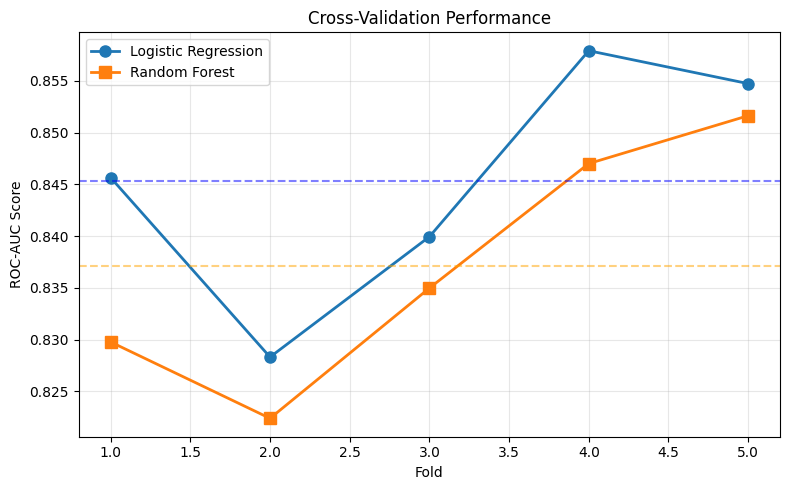

In [ ]:
print("CROSS-VALIDATION")


# Perform 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression CV
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, 
                                cv=cv, scoring='roc_auc')
print(f"\n Logistic Regression 5-Fold CV AUC Scores:")
print(f"   Scores: {lr_cv_scores}")
print(f"   Mean AUC: {lr_cv_scores.mean():.4f} (+/- {lr_cv_scores.std()*2:.4f})")

# Random Forest CV
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, 
                                cv=cv, scoring='roc_auc')
print(f"\n Random Forest 5-Fold CV AUC Scores:")
print(f"   Scores: {rf_cv_scores}")
print(f"   Mean AUC: {rf_cv_scores.mean():.4f} (+/- {rf_cv_scores.std()*2:.4f})")

# Visualize CV results
plt.figure(figsize=(8, 5))
plt.plot(range(1, 6), lr_cv_scores, 'o-', label='Logistic Regression', 
         linewidth=2, markersize=8)
plt.plot(range(1, 6), rf_cv_scores, 's-', label='Random Forest', 
         linewidth=2, markersize=8)
plt.axhline(y=lr_cv_scores.mean(), color='blue', linestyle='--', alpha=0.5)
plt.axhline(y=rf_cv_scores.mean(), color='orange', linestyle='--', alpha=0.5)
plt.xlabel('Fold')
plt.ylabel('ROC-AUC Score')
plt.title('Cross-Validation Performance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation.png', dpi=100, bbox_inches='tight')
plt.show()


DAY 4 SUMMARY - YOUR FIRST ML MODELS!

✅ WHAT YOU'VE ACCOMPLISHED TODAY:
   1. Split data into training and testing sets
   2. Scaled features for better model performance
   3. Trained a Logistic Regression model
   4. Trained a Random Forest model
   5. Evaluated models with multiple metrics
   6. Compared model performance visually
   7. Made predictions on new customers
   8. Performed cross-validation for robust evaluation

📊 MODEL PERFORMANCE SUMMARY:
   Metric  Logistic Regression  Random Forest
 Accuracy             0.799858       0.802697
Precision             0.652318       0.654839
   Recall             0.526738       0.542781
 F1-Score             0.582840       0.593567
  ROC-AUC             0.712644       0.719700

🏆 WINNER: Random Forest (better overall performance)

🔍 KEY INSIGHTS:
   1. Both models perform reasonably well (AUC > 0.8)
   2. The most important features are:
      - RiskScore: 0.167
      - MonthlyCharges: 0.147
      - TotalCharges: 0.144
   3. Month-to